# IPC Adherence Study — Exploratory Data Analysis
**Project:** Medical Students' Adherence to Infection Prevention Practices, OIU – 2025  
**Analyst:** Abdulrahman Sirelkhatim  
**Date:** January 2026  
**Sample:** N = 156 clinical-year medical students

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10

DATA_PATH = '../1_data/cleaned/cleaned_data.xlsx'
df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (156, 53)
Columns: ['ID', 'gender', 'age', 'year_of_study', 'ipc_training', 'heard_5moments', 'know_wash_tech', 'aware_risks', 'wash_before', 'wash_after', 'alcohol_rub', 'gloves', 'mask', 'sharp_disposal', 'needle_stick', 'time_pressure', 'staff_support', 'seniors_follow', 'observation_influence', 'training_type_lecture', 'training_type_workshop', 'training_type_online_course', 'training_type_bedside_teaching', 'training_type_others', 'moment_before_patient_contact', 'moment_after_patient_contact', 'moment_after_exposure_to_body_fluids', 'moment_before_cleaning__aseptic_procedures', 'moment_after_touching_patient_surroundings', 'barrier_personal_lack_of_knowledge', 'barrier_personal_forgetfulness', 'barrier_personal_poor_attitude', 'barrier_personal_lack_of_experience', 'barrier_hospital_overcrowding', 'barrier_hospital_lack_of_gloves_masks', 'barrier_hospital_no_alcohol_sanitizer', 'barrier_hospital_poor_facility_hygiene', 'barrier_hospital_inadequate_supervision', 'influence_

## 1. Data Quality

In [2]:
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')
print('\nDuplicate rows:', df.duplicated().sum())
print('\nAdherence Likert values:', sorted(df['wash_before'].dropna().unique().tolist()))
print('Knowledge score range:', df['knowledge_score'].min(), '-', df['knowledge_score'].max())
print('Total adherence range:', df['total_adherence_score'].min(), '-', df['total_adherence_score'].max())

Missing values per column:
No missing values.

Duplicate rows: 0

Adherence Likert values: [1, 2, 3, 4, 5]
Knowledge score range: 1 - 5
Total adherence range: 6 - 30


## 2. Demographic Profile

In [3]:
print('Gender:')
print(df['gender'].map({1:'Male', 2:'Female'}).value_counts())
print(f'\nAge: mean={df["age"].mean():.2f}, SD={df["age"].std():.2f}, range={df["age"].min()}-{df["age"].max()}')
print('\nYear of Study:')
print(df['year_of_study'].map({4:'4th Year', 5:'5th Year'}).value_counts())
print('\nIPC Training and Awareness (% Yes):')
for col, label in [('ipc_training','Previous Training'), ('heard_5moments','Heard 5 Moments'),
                   ('know_wash_tech','Knows Technique'), ('aware_risks','Aware of Risks')]:
    print(f'  {label}: {df[col].mean()*100:.1f}%')

Gender:
gender
Male      83
Female    73
Name: count, dtype: int64

Age: mean=23.40, SD=1.23, range=20-27

Year of Study:
year_of_study
5th Year    84
4th Year    72
Name: count, dtype: int64

IPC Training and Awareness (% Yes):
  Previous Training: 51.3%
  Heard 5 Moments: 65.4%
  Knows Technique: 67.3%
  Aware of Risks: 83.3%


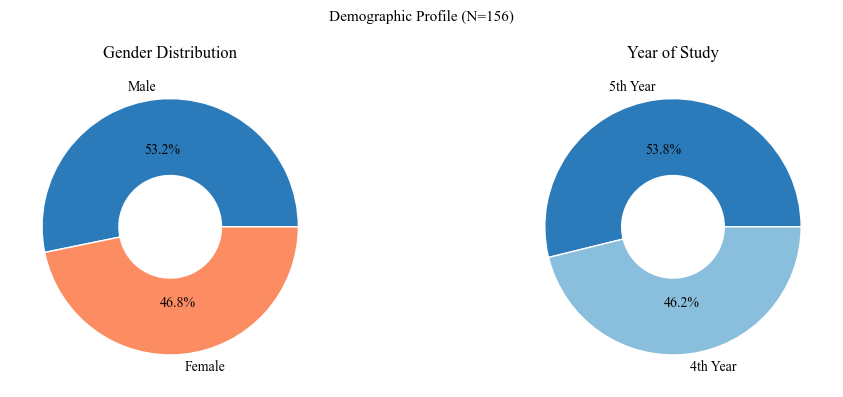

In [4]:
blue = sns.color_palette('Blues_r', 6)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gender_counts = df['gender'].map({1:'Male', 2:'Female'}).value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[blue[1], sns.color_palette('Set2')[1]],
            wedgeprops={'width': 0.6, 'edgecolor': 'white'})
axes[0].set_title('Gender Distribution')

yr_counts = df['year_of_study'].map({4:'4th Year', 5:'5th Year'}).value_counts()
axes[1].pie(yr_counts, labels=yr_counts.index, autopct='%1.1f%%',
            colors=[blue[1], blue[3]],
            wedgeprops={'width': 0.6, 'edgecolor': 'white'})
axes[1].set_title('Year of Study')
plt.suptitle('Demographic Profile (N=156)', fontsize=11)
plt.tight_layout()
plt.show()

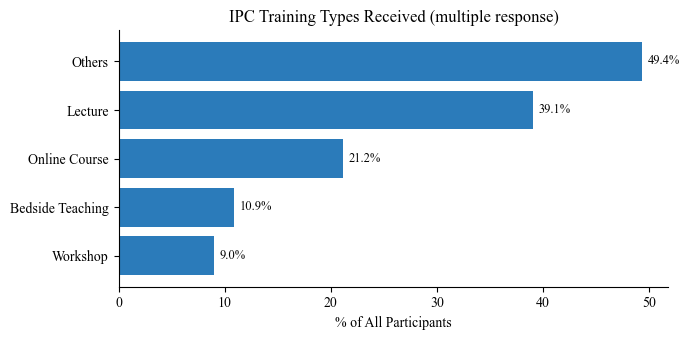

In [5]:
training_cols = ['training_type_lecture', 'training_type_workshop',
                 'training_type_online_course', 'training_type_bedside_teaching', 'training_type_others']
training_labels = ['Lecture', 'Workshop', 'Online Course', 'Bedside Teaching', 'Others']
train_pcts = {label: df[col].mean()*100 for col, label in zip(training_cols, training_labels)}
train_pcts = dict(sorted(train_pcts.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(list(train_pcts.keys()), list(train_pcts.values()), color=blue[1])
for k, v in train_pcts.items():
    ax.text(v + 0.5, list(train_pcts.keys()).index(k), f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of All Participants')
ax.set_title('IPC Training Types Received (multiple response)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Knowledge and Adherence Score Distributions

In [6]:
print('Score Descriptives:')
print(df[['knowledge_score', 'total_adherence_score', 'mean_adherence_score']].describe().round(2))

print('\nKnowledge Level Distribution:')
kl = df['knowledge_level'].map({1:'Poor', 2:'Moderate', 3:'Good'}).value_counts()
for k, v in kl.items():
    print(f'  {k}: {v} ({v/len(df)*100:.1f}%)')

print('\nAdherence Level Distribution:')
al = df['adherence_level'].map({1:'Poor', 2:'Moderate', 3:'Good'}).value_counts()
for k, v in al.items():
    print(f'  {k}: {v} ({v/len(df)*100:.1f}%)')

Score Descriptives:
       knowledge_score  total_adherence_score  mean_adherence_score
count           156.00                 156.00                156.00
mean              3.40                  22.71                  3.79
std               1.82                   4.80                  0.80
min               1.00                   6.00                  1.00
25%               1.00                  20.00                  3.33
50%               5.00                  24.00                  4.00
75%               5.00                  26.00                  4.33
max               5.00                  30.00                  5.00

Knowledge Level Distribution:
  Good: 91 (58.3%)
  Poor: 57 (36.5%)
  Moderate: 8 (5.1%)

Adherence Level Distribution:
  Good: 81 (51.9%)
  Moderate: 54 (34.6%)
  Poor: 21 (13.5%)


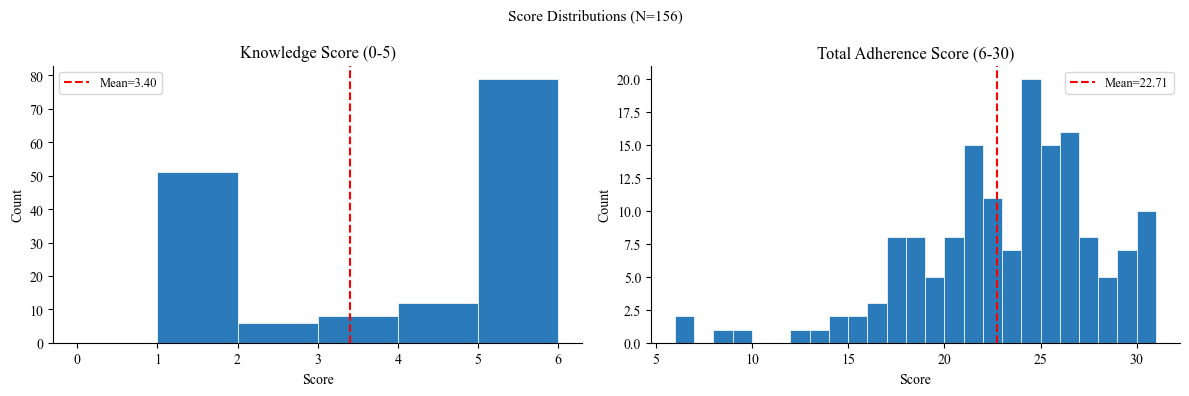

Note: Knowledge shows bimodal distribution — 57.1% good, 37.2% poor.
      Adherence is left-skewed — most students cluster at the good end.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, bins in zip(axes,
    ['knowledge_score', 'total_adherence_score'],
    ['Knowledge Score (0-5)', 'Total Adherence Score (6-30)'],
    [range(0, 7), range(6, 32)]):
    ax.hist(df[col], bins=bins, color=blue[1], edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean={df[col].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Score Distributions (N=156)', fontsize=11)
plt.tight_layout()
plt.show()

print('Note: Knowledge shows bimodal distribution — 57.1% good, 37.2% poor.')
print('      Adherence is left-skewed — most students cluster at the good end.')

## 4. Item-Level Analysis

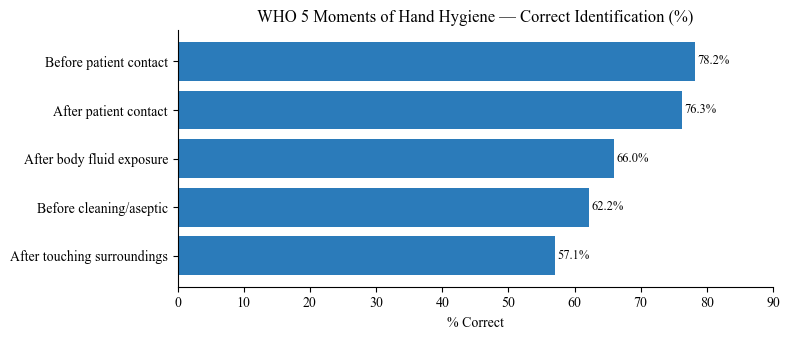

In [8]:
moment_cols = [c for c in df.columns if c.startswith('moment_')]
moment_labels = ['Before patient contact', 'After patient contact',
                 'After body fluid exposure', 'After touching surroundings',
                 'Before cleaning/aseptic']
moment_pcts = pd.Series({label: df[col].mean()*100
                         for col, label in zip(moment_cols, moment_labels)}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(moment_pcts.index, moment_pcts.values, color=blue[1])
for i, v in enumerate(moment_pcts.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% Correct')
ax.set_title('WHO 5 Moments of Hand Hygiene — Correct Identification (%)')
ax.set_xlim(0, 90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
adherence_items = ['wash_before', 'wash_after', 'alcohol_rub', 'gloves', 'mask', 'sharp_disposal']
adh_labels = ['Wash before contact', 'Wash after contact', 'Alcohol rub',
               'Gloves', 'Mask', 'Sharp disposal']

adh_means = pd.Series({label: df[col].mean() for col, label in zip(adherence_items, adh_labels)})
adh_always_often = pd.Series({label: (df[col] >= 4).mean()*100 for col, label in zip(adherence_items, adh_labels)})

print('Adherence item means and Always/Often %:')
for label in adh_labels:
    print(f'  {label}: mean={adh_means[label]:.2f}, Always/Often={adh_always_often[label]:.1f}%')
print('\nLowest: Sharp disposal (mean 3.16, 44.8% Always/Often)')

Adherence item means and Always/Often %:
  Wash before contact: mean=3.79, Always/Often=62.8%
  Wash after contact: mean=4.16, Always/Often=75.6%
  Alcohol rub: mean=3.72, Always/Often=59.0%
  Gloves: mean=4.06, Always/Often=72.4%
  Mask: mean=3.81, Always/Often=60.9%
  Sharp disposal: mean=3.16, Always/Often=44.9%

Lowest: Sharp disposal (mean 3.16, 44.8% Always/Often)


## 5. Barriers and Influencing Factors

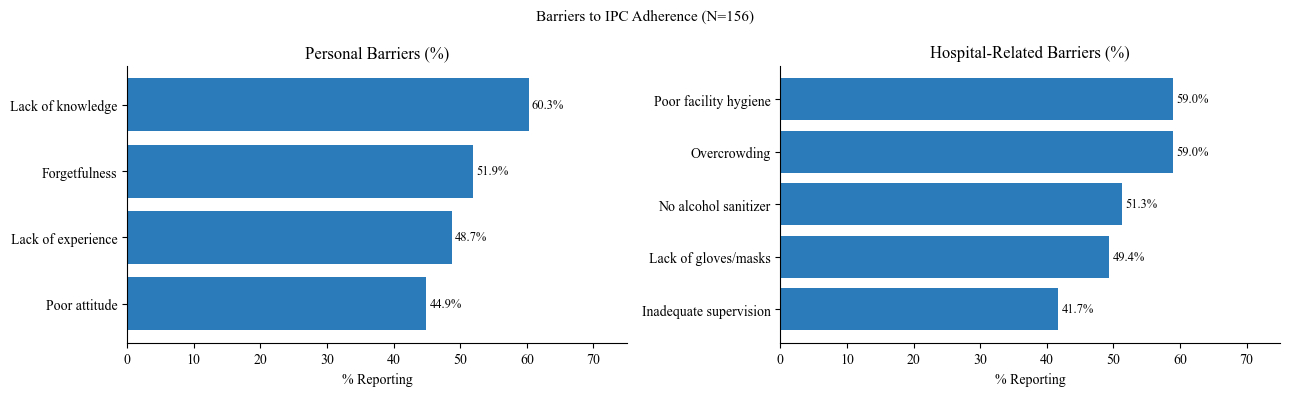


Barrier Summary:
       barriers_personal_sum  barriers_hospital_sum  barriers_total
count                 156.00                 156.00          156.00
mean                    2.06                   2.60            4.66
std                     1.11                   1.51            2.36
min                     1.00                   1.00            2.00
25%                     1.00                   1.00            2.00
50%                     2.00                   2.00            4.00
75%                     3.00                   4.00            6.25
max                     4.00                   5.00            9.00


In [10]:
p_barrier_cols = ['barrier_personal_lack_of_knowledge', 'barrier_personal_forgetfulness',
                  'barrier_personal_poor_attitude', 'barrier_personal_lack_of_experience']
p_labels = ['Lack of knowledge', 'Forgetfulness', 'Poor attitude', 'Lack of experience']
h_barrier_cols = ['barrier_hospital_overcrowding', 'barrier_hospital_lack_of_gloves_masks',
                  'barrier_hospital_no_alcohol_sanitizer', 'barrier_hospital_poor_facility_hygiene',
                  'barrier_hospital_inadequate_supervision']
h_labels = ['Overcrowding', 'Lack of gloves/masks', 'No alcohol sanitizer',
            'Poor facility hygiene', 'Inadequate supervision']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cols, labels, title in zip(axes,
    [p_barrier_cols, h_barrier_cols],
    [p_labels, h_labels],
    ['Personal Barriers (%)', 'Hospital-Related Barriers (%)']):
    pcts = pd.Series({label: df[col].mean()*100 for col, label in zip(cols, labels)}).sort_values()
    ax.barh(pcts.index, pcts.values, color=blue[1])
    for i, v in enumerate(pcts.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% Reporting')
    ax.set_title(title)
    ax.set_xlim(0, 75)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Barriers to IPC Adherence (N=156)', fontsize=11)
plt.tight_layout()
plt.show()

print('\nBarrier Summary:')
print(df[['barriers_personal_sum', 'barriers_hospital_sum', 'barriers_total']].describe().round(2))

## 6. Preliminary Associations

In [11]:
# Gender differences
for col, label in [('knowledge_score', 'Knowledge'), ('total_adherence_score', 'Adherence')]:
    male = df[df['gender'] == 1][col]
    female = df[df['gender'] == 2][col]
    t, p = stats.ttest_ind(male.dropna(), female.dropna())
    print(f'{label} by Gender: Male={male.mean():.2f}±{male.std():.2f}, '
          f'Female={female.mean():.2f}±{female.std():.2f}, t={t:.2f}, p={p:.3f}')

Knowledge by Gender: Male=3.11±1.84, Female=3.73±1.75, t=-2.14, p=0.034
Adherence by Gender: Male=22.23±4.24, Female=23.26±5.34, t=-1.34, p=0.182


In [12]:
# Senior staff behavior and adherence — ANOVA
groups = [df[df['seniors_follow'] == k]['total_adherence_score'].dropna() for k in range(1, 6)]
f, p = stats.f_oneway(*groups)
means_by_senior = df.groupby('seniors_follow')['total_adherence_score'].mean()
print('Mean adherence by senior staff IPC compliance:')
for k, v in means_by_senior.items():
    labels = {1:'Never', 2:'Rarely', 3:'Sometimes', 4:'Often', 5:'Always'}
    print(f'  {labels[k]}: {v:.2f}')
print(f'\nOne-way ANOVA: F={f:.2f}, p={p:.3f}')
print('Critical finding: Senior role-modeling is the strongest predictor of student adherence.')

Mean adherence by senior staff IPC compliance:
  Never: 11.00
  Rarely: 22.08
  Sometimes: 22.27
  Often: 22.96
  Always: 24.57

One-way ANOVA: F=6.63, p=0.000
Critical finding: Senior role-modeling is the strongest predictor of student adherence.


In [13]:
# Knowledge vs Adherence — the know-do gap
r, p = stats.pearsonr(df['knowledge_score'], df['total_adherence_score'])
print(f'Pearson r (Knowledge × Adherence): r={r:.3f}, p={p:.3f}')
print('Interpretation: Knowledge does NOT predict adherence — confirms the IPC know-do gap.')

r2, p2 = stats.spearmanr(df['seniors_follow'].dropna(), df['total_adherence_score'].dropna())
print(f'\nSpearman ρ (Senior Staff Compliance × Adherence): ρ={r2:.3f}, p={p2:.3f}')

Pearson r (Knowledge × Adherence): r=-0.073, p=0.364
Interpretation: Knowledge does NOT predict adherence — confirms the IPC know-do gap.

Spearman ρ (Senior Staff Compliance × Adherence): ρ=0.211, p=0.008


In [14]:
# Training received — null finding visualization
trained = df[df['ipc_training'] == 1]
untrained = df[df['ipc_training'] == 0]
t, p = stats.ttest_ind(trained['total_adherence_score'], untrained['total_adherence_score'])
print(f'Adherence by Training: Trained={trained["total_adherence_score"].mean():.2f}, '
      f'Untrained={untrained["total_adherence_score"].mean():.2f}, t={t:.2f}, p={p:.3f}')
print('Null finding: Previous IPC training did not significantly improve adherence.')

Adherence by Training: Trained=23.30, Untrained=22.09, t=1.58, p=0.117
Null finding: Previous IPC training did not significantly improve adherence.


## 7. Correlation Analysis

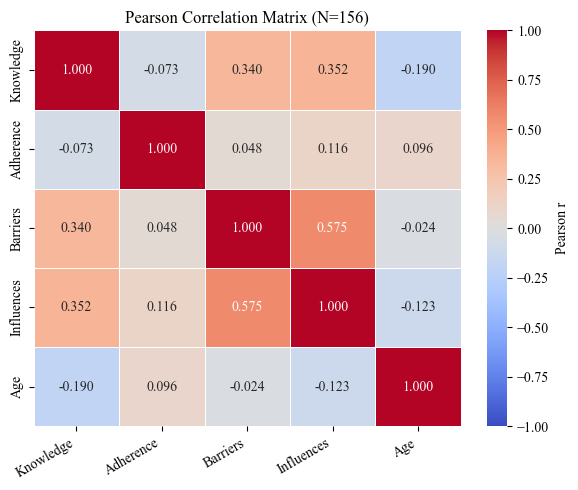


Key correlations:
  Knowledge × Adherence: r=-0.073 (non-significant)
  Knowledge × Barriers: r=0.340 (p<0.01)
  Knowledge × Influences: r=0.352 (p<0.01)


In [15]:
corr_vars = ['knowledge_score', 'total_adherence_score', 'barriers_total', 'influences_sum', 'age']
corr_labels = ['Knowledge', 'Adherence', 'Barriers', 'Influences', 'Age']

rho = df[corr_vars].corr()
rho.index = corr_labels
rho.columns = corr_labels

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(rho, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Pearson Correlation Matrix (N=156)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nKey correlations:')
print(f'  Knowledge × Adherence: r={rho.loc["Knowledge","Adherence"]:.3f} (non-significant)')
print(f'  Knowledge × Barriers: r={rho.loc["Knowledge","Barriers"]:.3f} (p<0.01)')
print(f'  Knowledge × Influences: r={rho.loc["Knowledge","Influences"]:.3f} (p<0.01)')

## 8. EDA Summary

## Summary of EDA Findings

| Finding | Value |
|----------|---------|
| Sample size | N = 156 |
| Male participants | 53.2% |
| Mean age | 23.40 ± 1.23 years |
| Previous IPC training | 51.3% |
| Knows WHO 5 Moments for Hand Hygiene | 65.4% |
| Mean knowledge score | 3.40 ± 1.82 |
| Good knowledge level | 58.3% |
| Mean total adherence score | 22.71 ± 4.80 |
| Good adherence level | 51.9% |
| Lowest adherence item | Sharp disposal (mean = 3.16; 30.8% reported never/rarely adhering) |
| Top personal barrier | Lack of knowledge (60.3%) |
| Top hospital barriers | Overcrowding (59.0%) and poor hygiene environment (59.0%) |
| Main factor influencing adherence | Hospital environment (67.9%) |
| Knowledge–adherence correlation | r = -0.051, p = 0.529 (not significant) |
| Significant t-test findings | Gender associated with knowledge score (p = 0.039); knowledge of IPC techniques associated with adherence score (p = 0.026) |
| Significant ANOVA finding | Perceived senior staff compliance associated with adherence score (F = 6.63, p < 0.001) |
| Significant regression predictor | Senior staff compliance (β = 0.24, p = 0.004) |

Formal bivariate and multivariable analyses were conducted in SPSS (see `4_analysis/full_analysis.sps`).